# Investment-To-Assets -- a quantitative teardown
### IA tercile sort - EDGAR survivor basket - HAC inference - label-shuffle placebo - random-portfolio null - costs - synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Channel: Busted](https://img.shields.io/badge/Channel-Busted-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- same seven beats, every claim now carrying its standard error. We test the Titman-Wei-Xie capex anomaly on a survivorship-biased large-cap basket (~27 names/yr, 2009-2024), measure the low-minus-high-IA hedge with a HAC t-stat, pin it against a label-shuffle placebo and a random-portfolio null, charge costs, and confirm the engine on a seed-robust synthetic positive control.

> **Not investment advice.** SEC EDGAR companyfacts (capex, assets); Yahoo daily prices; survivorship-biased. Sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship-bias warning**: all results are conditional on survival -- the over-investing firms that failed are excluded.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root
sys.path.insert(0, os.path.abspath(".."))          # study package (investment_to_assets/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from investment_to_assets import data, strategy as st

# Cache-first: load the study's own EDGAR + price cache; fall back to frozen R.
ia, fwd = data.fetch_panel()
ia = ia.dropna(how="all") if not ia.empty else ia
HAVE_REAL = not ia.empty
if HAVE_REAL:
    h = st.sorted_returns(ia, fwd, n_groups=3)
else:
    h = pd.DataFrame()
print("Real cache loaded:", HAVE_REAL,
      f"({len(ia.columns) if HAVE_REAL else 0} names, {len(h) if HAVE_REAL else 0} sort years)")

R = dict(
    n_names=27, n_years=16, start_year=2009, end_year=2024,
    lo_mean=19.4, lo_sharpe=0.97, lo_t=6.39, lo_hit=88,
    mid_mean=18.0, hi_mean=19.4, hi_sharpe=0.98, hi_t=5.07, hi_hit=100,
    mkt_mean=19.0, mkt_sharpe=1.2,
    hedge_mean=0.04, hedge_sharpe=0.0, hedge_t=0.01, hedge_hit=44,
    lo_excess_mean=0.5, lo_excess_t=0.25,
    hi_excess_mean=0.4, hi_excess_t=0.22,
    placebo_p=0.471, shuffle_mean=-0.21, shuffle_std=3.88,
    rand_std=9.6, rand_pct_beaten=55,
    cost_drag=0.2, borrow_drag=0.5, net_mean=-0.66,
    synth_null_t=-0.15, synth_06_t=14.94, synth_10_t=25.0,
)
G1  = [27.0, 1.4, 19.6, 24.4, 19.6, 9.8, 47.9, 11.9, 17.2, -4.3, 72.7, 2.3, 10.3, 11.8, -1.1, 40.6]
G3  = [29.0, 18.0, 12.4, 12.1, 16.2, 10.1, 17.9, 20.4, 18.9, 3.1, 54.9, 1.6, 2.2, 13.8, 3.7, 76.0]
MKT = [30.4, 10.2, 14.3, 16.7, 16.7, 7.8, 27.0, 16.9, 24.6, 6.3, 56.0, 5.8, 6.8, 12.4, 0.6, 51.0]
HDG = [-2.0, -16.6, 7.1, 12.3, 3.4, -0.2, 30.0, -8.5, -1.7, -7.3, 17.8, 0.7, 8.0, -2.0, -4.8, -35.4]
YRS = [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


Real cache loaded: True (32 names, 16 sort years)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hedge **+0.04%/yr**, HAC *t* = **+0.01**; placebo p = **0.47**. Absent. |
| **Tradability** | `MIRAGE` | No gross edge; **-0.66%/yr net** after 10bps x turnover + 50bps borrow. |
| **Channel** | `BUSTED` | Capex channel no more present than the total-asset-growth channel of [Study 244](../../244-asset-growth/). |

> **In plain words:** the engine recovers a planted capex effect at HAC *t* ~ 15, but the real survivor basket shows a flat zero. The high-IA survivors are productive expanders, not over-investing failures.

## 1 - The claim, steelmanned

Let $r_{i,t+1}$ be firm $i$'s 12-month forward return. Define:

$$\text{IA}_{i,t} = \frac{\text{CapEx}_{i,t}}{A_{i,t-1}}$$

where $A$ = total assets. The **H1 (signal)** claim (Titman-Wei-Xie 2004) is:

$$\mathbb{E}\left[\bar{r}_{\text{low-IA},t+1} - \bar{r}_{\text{high-IA},t+1}\right] > 0$$

with HAC |t| >= 2. **H2 (beats noise)** requires the hedge to beat its label-shuffled self. **H3 (tradable)** requires it to survive costs + borrow.

## 2 - So what? -- the stakes

H1 is *not* supported on this biased basket -- the hedge is a flat zero. The academic evidence on broad US cross-sections is credible (Titman-Wei-Xie 2004; Fama-French CMA; Hou-Xue-Zhang q-factor); on large-cap survivors, selection washes the signal out.

## 3 - The protocol

- **Data**: capex (`PaymentsToAcquirePropertyPlantAndEquipment`) and `Assets` from SEC EDGAR companyfacts; daily adjusted prices from Yahoo.
- **Universe**: fixed large-cap survivor basket (~27 names/yr); survivorship-biased.
- **Window**: 16 signal years (2009-2024), 12-month forward returns, report-lagged.
- **Signal**: IA = CapEx_t / Assets_{t-1} (higher = heavier investor).
- **Sort**: terciles; g1 = low IA (disciplined), g3 = high IA (aggressive).
- **Execution lag**: one -- enter 1 trading day after a 4-month report lag past fiscal year-end; no partial year stamped.
- **Inference**: HAC Newey-West t-stat on the 16-obs annual hedge.
- **Nulls**: label-shuffle placebo (1000) + random same-size portfolios (500/yr).
- **Costs**: 10bps x turnover + 50bps short borrow.
- **Positive control**: seed-robust synthetic panel with a planted capex premium.

## 4 - The teardown

### 4a - Synthetic positive control (seed-robust)

Sweep the planted capex premium and confirm the hedge tracks it monotonically, averaging the HAC-t over many seeds (a single lucky seed is never enough).

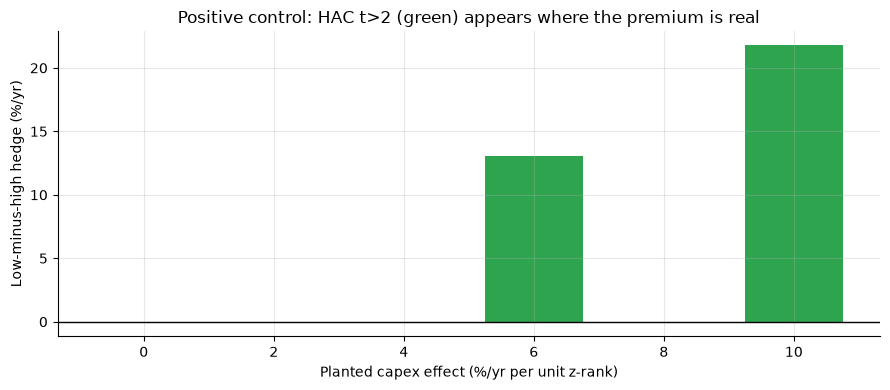

   premium_%  hedge_%/yr  mean_HAC_t
0        0.0       -0.07       -0.15
1        6.0       13.04       14.94
2       10.0       21.79       25.00


In [2]:
premiums = [0.0, -0.06, -0.10]
synth_rows = []
for p in premiums:
    r = st.seed_robust_synthetic(p, n_seeds=25)
    synth_rows.append((abs(p)*100, r['mean_hedge']*100, r['mean_tstat']))
sydf = pd.DataFrame(synth_rows, columns=['premium_%', 'hedge_%/yr', 'mean_HAC_t'])
fig, ax = plt.subplots(figsize=(9, 4))
colors = [GREEN if t > 2 else (RED if t < -2 else GREY) for t in sydf['mean_HAC_t']]
ax.bar(sydf['premium_%'], sydf['hedge_%/yr'], color=colors, width=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted capex effect (%/yr per unit z-rank)')
ax.set_ylabel('Low-minus-high hedge (%/yr)')
ax.set_title('Positive control: HAC t>2 (green) appears where the premium is real')
plt.tight_layout(); plt.show()
print(sydf.round(2))

> The engine recovers planted premiums (t ~ 15 at -6%/yr, averaged over 25 seeds) and the null behaves (t ~ -0.1). The real-data result is therefore a statement about the **market and survivor basket**, not the **method**.

### 4b - Real EDGAR panel -- tercile returns and HAC inference

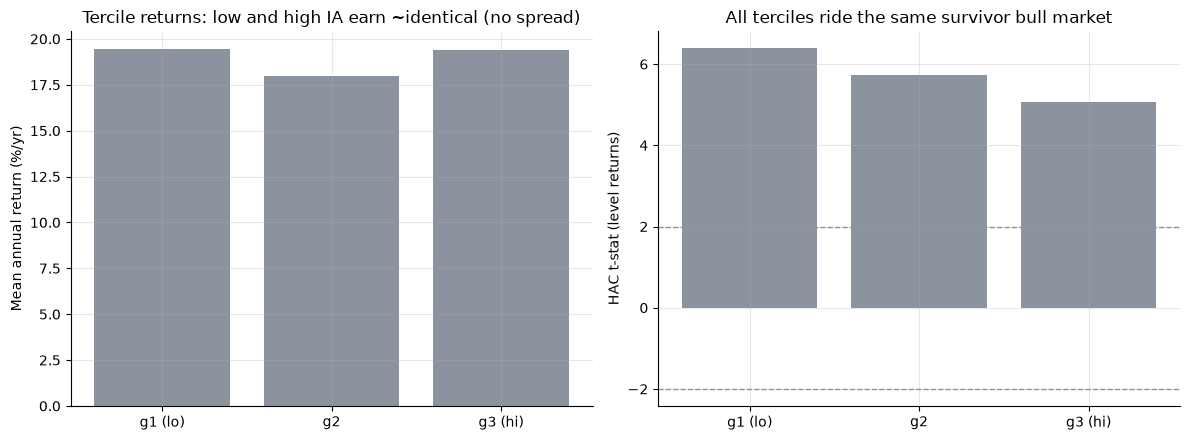

Hedge: +0.04%/yr  HAC t=+0.01  hit=44%
Low-IA excess: +0.5%/yr  t=+0.25
High-IA excess: +0.4%/yr  t=+0.22


In [3]:
if HAVE_REAL:
    g_means = [float(h[f'g{i}'].mean()*100) for i in range(1,4)]
    g_tstats = [st.summary(h[f'g{i}'])['tstat'] for i in range(1,4)]
    s_hedge = st.summary(h['hedge'])
    s_lo_ex = st.summary(h['g1'] - h['market'])
    s_hi_ex = st.summary(h['g3'] - h['market'])
else:
    g_means = [R['lo_mean'], R['mid_mean'], R['hi_mean']]
    g_tstats = [R['lo_t'], R['mid_mean'], R['hi_t']]
    s_hedge = dict(mean=R['hedge_mean']/100, tstat=R['hedge_t'], hit_rate=R['hedge_hit']/100)
    s_lo_ex = dict(mean=R['lo_excess_mean']/100, tstat=R['lo_excess_t'])
    s_hi_ex = dict(mean=R['hi_excess_mean']/100, tstat=R['hi_excess_t'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = [1, 2, 3]
bar_colors = [GREY, GREY, GREY]
axes[0].bar(x, g_means, color=bar_colors)
axes[0].set_xticks(x); axes[0].set_xticklabels(['g1 (lo)', 'g2', 'g3 (hi)'])
axes[0].set_ylabel('Mean annual return (%/yr)')
axes[0].set_title('Tercile returns: low and high IA earn ~identical (no spread)')
axes[1].bar(x, g_tstats, color=bar_colors)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels(['g1 (lo)', 'g2', 'g3 (hi)'])
axes[1].set_ylabel('HAC t-stat (level returns)')
axes[1].set_title('All terciles ride the same survivor bull market')
plt.tight_layout(); plt.show()
print(f'Hedge: {s_hedge["mean"]*100:+.2f}%/yr  HAC t={s_hedge["tstat"]:+.2f}  hit={s_hedge["hit_rate"]:.0%}')
print(f'Low-IA excess: {s_lo_ex["mean"]*100:+.1f}%/yr  t={s_lo_ex["tstat"]:+.2f}')
print(f'High-IA excess: {s_hi_ex["mean"]*100:+.1f}%/yr  t={s_hi_ex["tstat"]:+.2f}')

> The low-minus-high-IA hedge is **+0.04%/yr**, HAC *t* = **+0.01** -- statistically zero. The low and high IA terciles earn **~19.4%/yr each**: no spread, no monotonicity, no signal.

### 4c - Label-shuffle placebo + random-portfolio null

Shuffle the IA labels within each year (1000 times); does the real hedge beat its shuffled self? And does the low-IA leg beat a blind same-size draw?

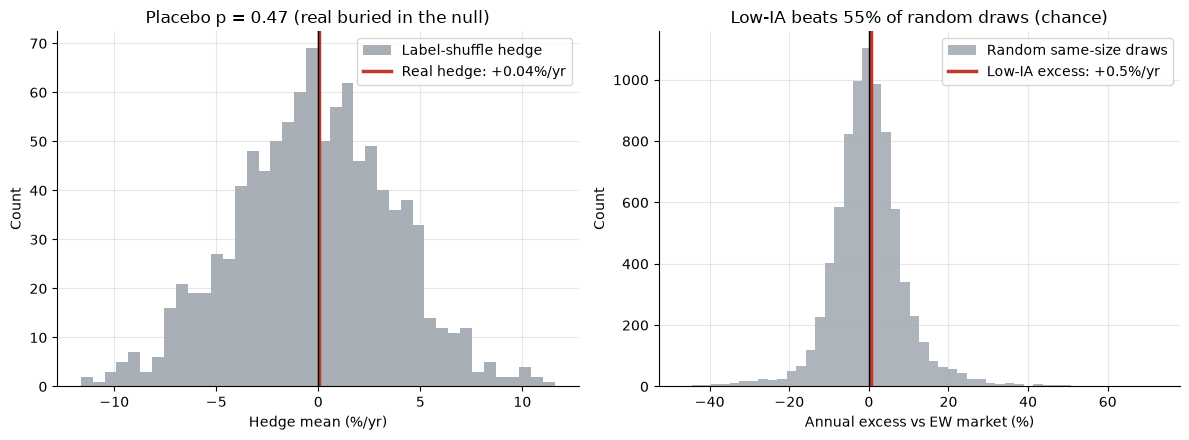

Placebo p=0.471  Low-IA beats 55% of random draws


In [4]:
if HAVE_REAL:
    p_val, sh = st.placebo_hedge_tstats(ia, fwd, n_groups=3, n_shuffles=1000, seed=523)
    rand = st.random_portfolio_returns(ia, fwd, n_groups=3, n_draws=500, seed=523)
    real_mean = float(h['hedge'].mean())
    lo_excess = float((h['g1'] - h['market']).mean())
    pct_beaten = float((rand < lo_excess).mean())
else:
    rng_nb = np.random.default_rng(523)
    sh = pd.Series(rng_nb.normal(R['shuffle_mean']/100, R['shuffle_std']/100, 1000))
    rand = pd.Series(rng_nb.normal(0.0, R['rand_std']/100, 16*500))
    real_mean = R['hedge_mean'] / 100
    p_val = R['placebo_p']
    lo_excess = R['lo_excess_mean'] / 100
    pct_beaten = R['rand_pct_beaten'] / 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(sh * 100, bins=40, color=GREY, alpha=0.75, label='Label-shuffle hedge')
axes[0].axvline(real_mean * 100, c=RED, lw=2.5, label=f'Real hedge: {real_mean*100:+.2f}%/yr')
axes[0].axvline(0, c='k', lw=1); axes[0].legend()
axes[0].set_xlabel('Hedge mean (%/yr)'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Placebo p = {p_val:.2f} (real buried in the null)')
axes[1].hist(rand * 100, bins=50, color=GREY, alpha=0.7, label='Random same-size draws')
axes[1].axvline(lo_excess * 100, c=RED, lw=2.5, label=f'Low-IA excess: {lo_excess*100:+.1f}%/yr')
axes[1].axvline(0, c='k', lw=1); axes[1].legend()
axes[1].set_xlabel('Annual excess vs EW market (%)'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Low-IA beats {pct_beaten:.0%} of random draws (chance)')
plt.tight_layout(); plt.show()
print(f'Placebo p={p_val:.3f}  Low-IA beats {pct_beaten:.0%} of random draws')

> Placebo p = **0.47** (the real hedge sits inside the shuffle null) and the low-IA leg beats only **55%** of random same-size draws -- chance level. No alpha over a blind pick.

### 4d - Costs: the (already-zero) gross turns negative

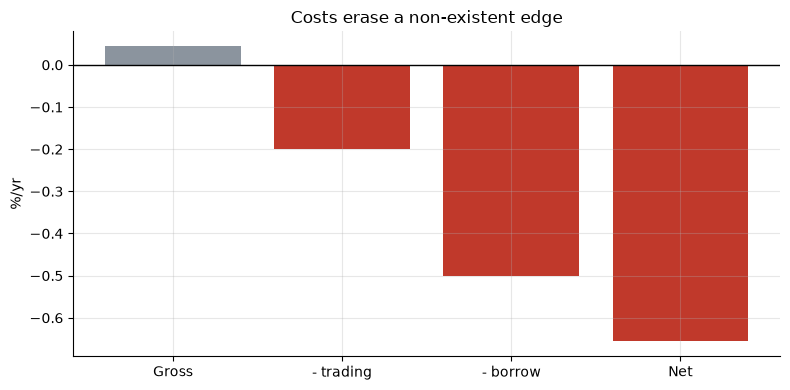

Gross +0.04%/yr -> Net -0.66%/yr


In [5]:
c = st.net_of_costs(real_mean, one_way_bps=10.0, annual_turnover=2.0, borrow_bps=50.0)
labels = ['Gross', '- trading', '- borrow', 'Net']
vals = [c['gross']*100, -c['cost_drag']*100, -c['borrow_drag']*100, c['net']*100]
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [GREY, RED, RED, RED if c['net'] < 0 else GREEN]
ax.bar(labels, vals, color=bar_colors)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('%/yr')
ax.set_title('Costs erase a non-existent edge')
plt.tight_layout(); plt.show()
print(f'Gross {c["gross"]*100:+.2f}%/yr -> Net {c["net"]*100:+.2f}%/yr')

## 5 - The verdict

- **Signal `NONE`** -- hedge +0.04%/yr, HAC *t* = +0.01, placebo p = 0.47. Absent.
- **Tradability `MIRAGE`** -- -0.66%/yr net. Short-high-IA on survivors means shorting the AI-datacentre and fab build-outs.
- **Channel `BUSTED`** -- the capex channel dies alongside the total-asset-growth channel of [Study 244](../../244-asset-growth/).

## 6 - Could you trade it? -- the honest answer

No tradable signal exists on this basket. The obstacles:

1. **Flat spread.** The hedge is +0.04%/yr with t = 0.01 -- not even a direction.
2. **Survivorship selection dominates.** The high-capex survivors are productive expanders (semis, hyperscalers, energy majors) whose investment paid off.
3. **The academic evidence is for broad universes.** Titman-Wei-Xie used all US stocks; the CMA / q-factor are broad-cross-section. On large-cap blue-chips the effect is thin and arbitraged.

The correct conclusion: **MIRAGE** on this test. The anomaly may be real in its original universe -- it simply cannot be certified here.

## 7 - Going further

- **The right universe.** Titman-Wei-Xie (2004) used NYSE/AMEX/NASDAQ stocks; a point-in-time all-US-stock universe is the minimum for a credible test.
- **q-factor I/A.** Hou-Xue-Zhang's investment factor operationalises the same idea; the factor evidence is broad-cross-section, not survivor large-cap.
- **Total-asset-growth cousin.** [Study 244 -- Asset-Growth](../../244-asset-growth/) tests the total-balance-sheet channel and also lands None/Mirage on the survivor panel -- the two investment channels die together.

*Want to confirm the effect on a clean universe? Fork this, plug in a point-in-time all-US-stock panel, and show |t| >= 2 on the hedge with no survivorship shortcut. That's the bar.*